# 08 — Trend ID
Classify trend direction and segment candle windows into impulse/retracement legs.

In [26]:
# Cell 1 — Setup
%matplotlib inline

import sys
from pathlib import Path

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.adapters.local_data import load_ohlc_from_csv
from src.core.trend_id import identify_trend

processed_dir = ROOT / 'data' / 'processed'

candles_15m = load_ohlc_from_csv(processed_dir / 'R_10_15m.csv')
candles_1h  = load_ohlc_from_csv(processed_dir / 'R_10_1H.csv')

print(f'R_10_15m : {len(candles_15m)} candles  '
      f'({candles_15m[0].timestamp} → {candles_15m[-1].timestamp})')
print(f'R_10_1H  : {len(candles_1h)} candles  '
      f'({candles_1h[0].timestamp} → {candles_1h[-1].timestamp})')

R_10_15m : 1000 candles  (2026-02-11 13:45:00 → 2026-02-21 23:30:00)
R_10_1H  : 1000 candles  (2026-01-11 08:00:00 → 2026-02-21 23:00:00)


In [27]:
# Cell 2 — Run identify_trend and print leg tables

def print_leg_table(result, label):
    trend   = result['trend']
    legs    = result['legs']
    phase   = result['current_phase']
    print(f'\n--- {label} ---')
    print(f'Trend: {trend}   Legs: {len(legs)}   Current phase: {phase}')
    if not legs:
        print('  (no legs)')
        return
    hdr = f"{'type':<14} {'start_date':<22} {'start_price':>12}  {'end_date':<22} {'end_price':>12}  {'slope':>10}  {'confirmed'}"
    print(hdr)
    print('-' * len(hdr))
    for leg in legs:
        sd = str(leg['start_timestamp'])[:19] if leg['start_timestamp'] else ''
        ed = str(leg['end_timestamp'])[:19]   if leg['end_timestamp']   else 'open'
        ep = f"{leg['end_price']:>12.4f}"     if leg['end_price'] is not None else f"{'open':>12}"
        sl = f"{leg['slope']:>10.4f}"         if leg['slope'] is not None     else f"{'—':>10}"
        print(f"{leg['type']:<14} {sd:<22} {leg['start_price']:>12.4f}  {ed:<22} {ep}  {sl}  {leg['confirmed']}")


result_15m = identify_trend(candles_15m)
result_1h  = identify_trend(candles_1h)

print_leg_table(result_15m, 'R_10  15m')
print_leg_table(result_1h,  'R_10  1H')


--- R_10  15m ---
Trend: down   Legs: 4   Current phase: retracement
type           start_date              start_price  end_date                  end_price       slope  confirmed
--------------------------------------------------------------------------------------------------------------
impulse        2026-02-11 15:30:00       5322.4860  2026-02-18 19:15:00       5118.2190     -0.2973  True
retracement    2026-02-18 19:15:00       5118.2190  2026-02-21 16:45:00       5104.4490     -0.0495  True
impulse        2026-02-21 16:45:00       5104.4490  2026-02-21 22:30:00       5066.0590     -1.6691  True
retracement    2026-02-21 22:30:00       5066.0590  open                           open           —  False

--- R_10  1H ---
Trend: down   Legs: 6   Current phase: retracement
type           start_date              start_price  end_date                  end_price       slope  confirmed
-------------------------------------------------------------------------------------------------------

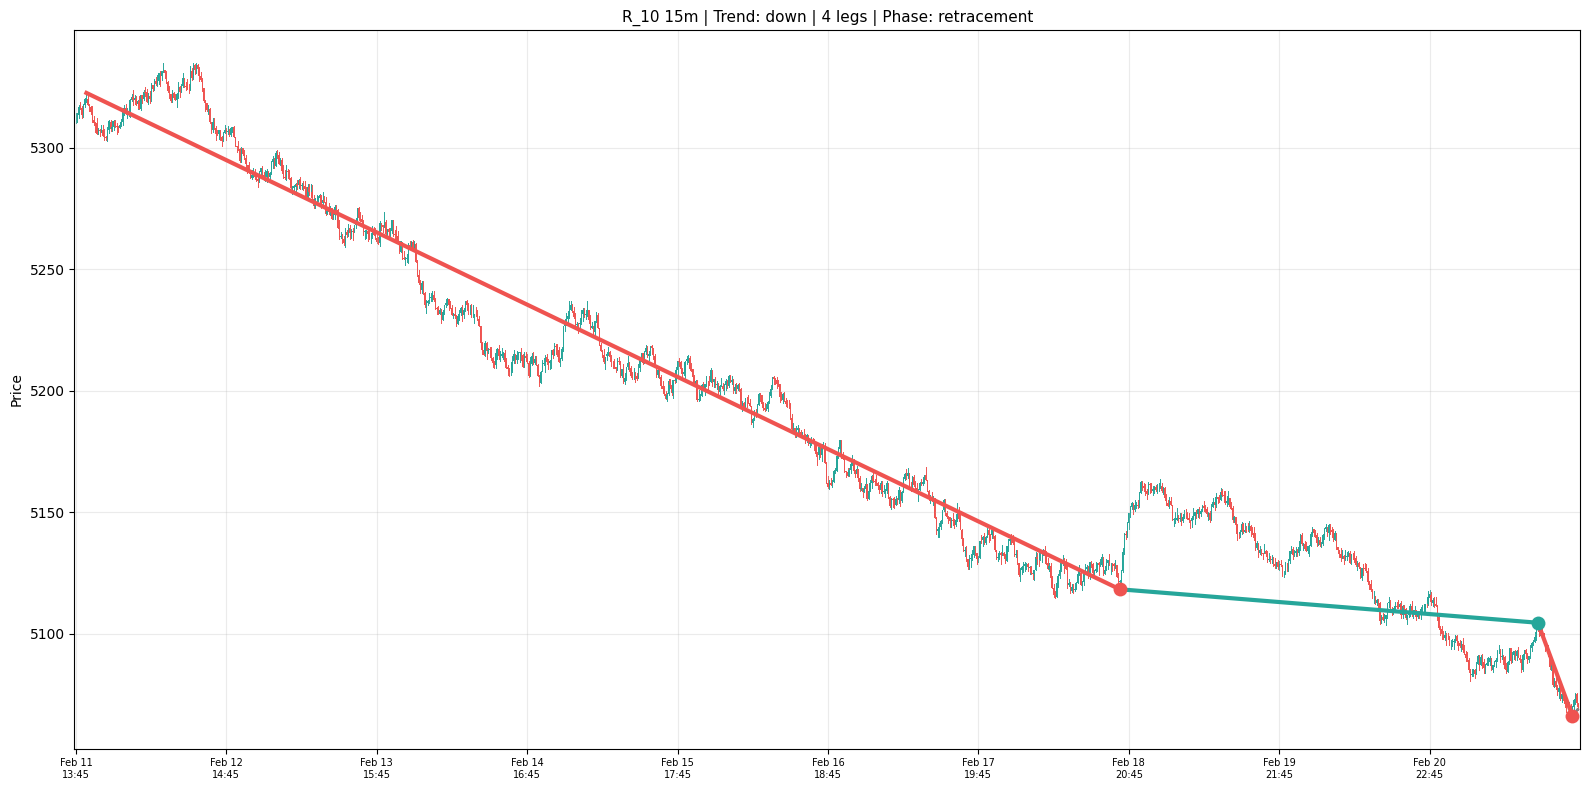

In [28]:
# Cell 3 — Visualise 15m  (last 200 candles)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

UP_COLOR   = '#26a69a'
DOWN_COLOR = '#ef5350'


def draw_trend_chart(candles, result, symbol, timeframe, figsize=(16, 8)):
    """Candlestick chart with leg overlays."""
    #WINDOW = min(200, len(candles))
    #display = candles[-WINDOW:]
    #offset  = len(candles) - WINDOW   # global → display index: di = global - offset

    WINDOW = len(candles)
    display = candles
    offset  = 0

    trend  = result['trend']
    legs   = result['legs']
    phase  = result['current_phase']

    fig, ax = plt.subplots(figsize=figsize)

    # ── Candlesticks ─────────────────────────────────────────────────────────
    for i, c in enumerate(display):
        color   = UP_COLOR if c.close >= c.open else DOWN_COLOR
        body_lo = min(c.open, c.close)
        body_hi = max(c.open, c.close)
        body_h  = max(body_hi - body_lo, (c.high - c.low) * 0.01)
        ax.plot([i, i], [c.low, c.high], color=color, linewidth=0.7, zorder=1)
        ax.add_patch(Rectangle(
            (i - 0.4, body_lo), 0.8, body_h,
            facecolor=color, edgecolor=color, linewidth=0, zorder=2,
        ))

    # ── Leg lines ─────────────────────────────────────────────────────────────
    for leg in legs:
        si = leg['start_index'] - offset
        sp = leg['start_price']

        if leg['confirmed'] and leg['end_index'] is not None:
            ei = leg['end_index'] - offset
            ep = leg['end_price']

            if trend == 'down':
                color = DOWN_COLOR if leg['type'] == 'impulse' else UP_COLOR
            else:
                color = UP_COLOR if leg['type'] == 'impulse' else DOWN_COLOR

            # clip to display window
            if ei < 0 or si >= WINDOW:
                continue
            si_c = max(si, 0)
            ei_c = min(ei, WINDOW - 1)
            if si_c == ei_c:
                continue
            # interpolate price at clipped boundaries
            frac = (ei_c - si_c) / (ei - si) if (ei - si) != 0 else 1
            ep_c = sp + (ep - sp) * frac if si_c != si else ep
            sp_c = sp if si_c == si else sp + (ep - sp) * ((si_c - si) / (ei - si))

            ax.plot([si_c, ei_c], [sp_c, ep_c],
                    color=color, linewidth=3, zorder=4)

            # Endpoint dot
            dot_color = DOWN_COLOR if leg['type'] == 'impulse' else UP_COLOR
            if 0 <= ei_c < WINDOW:
                ax.scatter(ei_c, ep, color=dot_color, s=100, zorder=6, linewidths=0)

        else:
            # Open / unconfirmed leg — draw as dashed grey line to last candle
            ei = WINDOW - 1
            ep = display[-1].close
            si_c = max(si, 0)
            if si_c >= WINDOW:
                continue
            ax.plot([si_c, ei], [sp, ep],
                    color='grey', linewidth=2, linestyle='--', zorder=3)

    # ── X-axis ───────────────────────────────────────────────────────────────
    tick_step = max(1, WINDOW // 10)
    tick_pos  = list(range(0, len(display), tick_step))
    tick_lbl  = [display[i].timestamp.strftime('%b %d\n%H:%M') for i in tick_pos]
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_lbl, fontsize=7)
    ax.set_xlim(-1, WINDOW)
    ax.set_ylabel('Price')
    ax.grid(True, alpha=0.25)

    n_legs = len(legs)
    ax.set_title(
        f"{symbol} {timeframe} | Trend: {trend} | "
        f"{n_legs} legs | Phase: {phase}",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()


draw_trend_chart(candles_15m, result_15m, 'R_10', '15m', figsize=(16, 8))

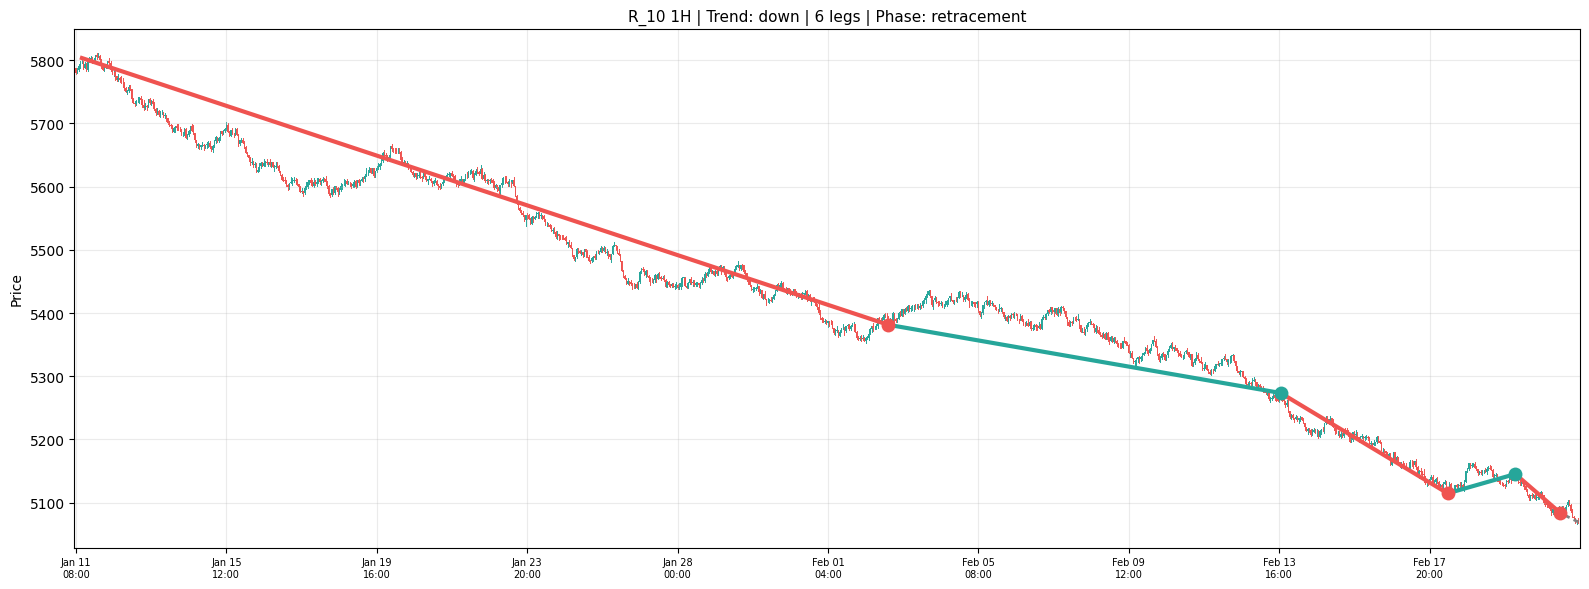

In [29]:
# Cell 4 — Visualise 1H
draw_trend_chart(candles_1h, result_1h, 'R_10', '1H', figsize=(16, 6))

1m: 1000 candles | trend=down | legs=4 | phase=retracement


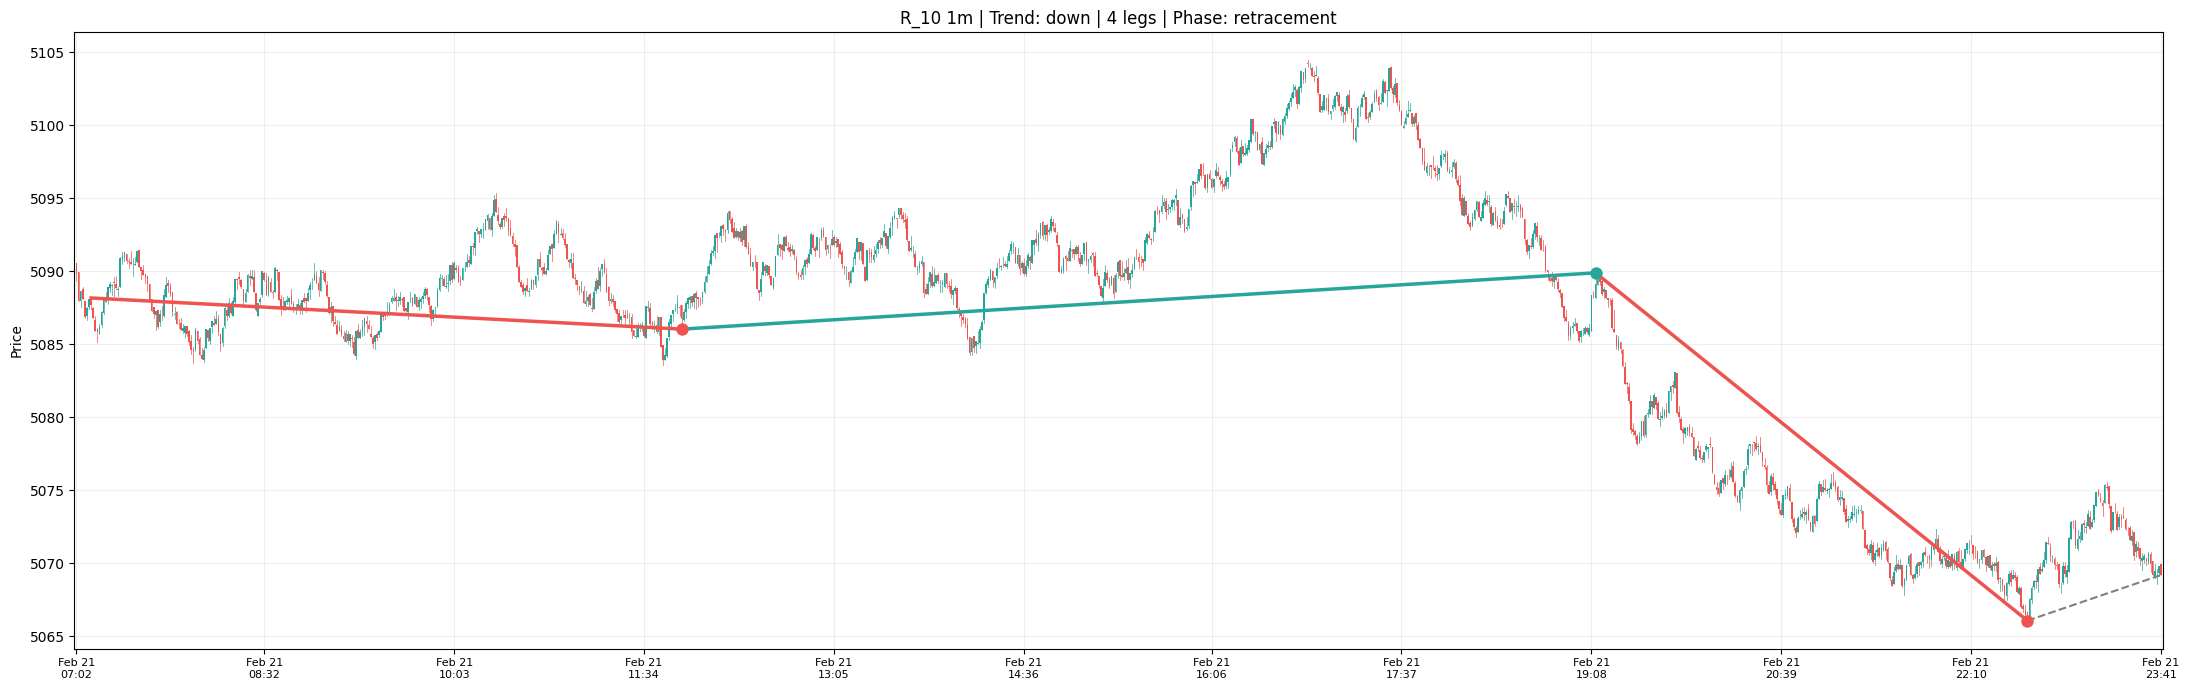

5m: 1000 candles | trend=down | legs=4 | phase=retracement


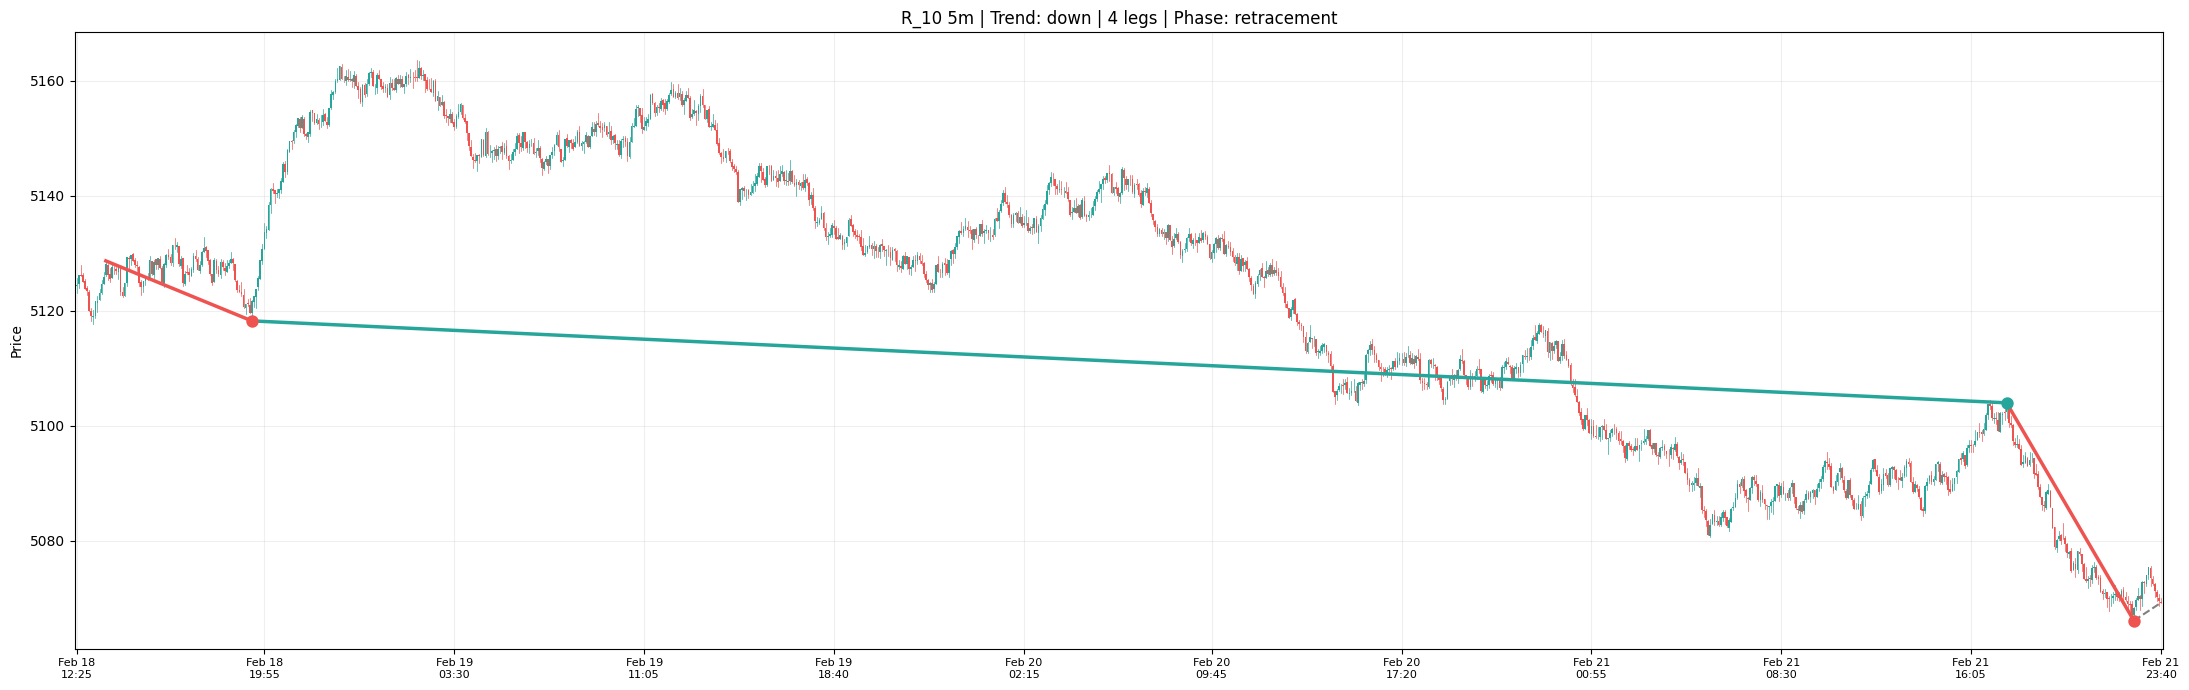

15m: 1000 candles | trend=down | legs=4 | phase=retracement


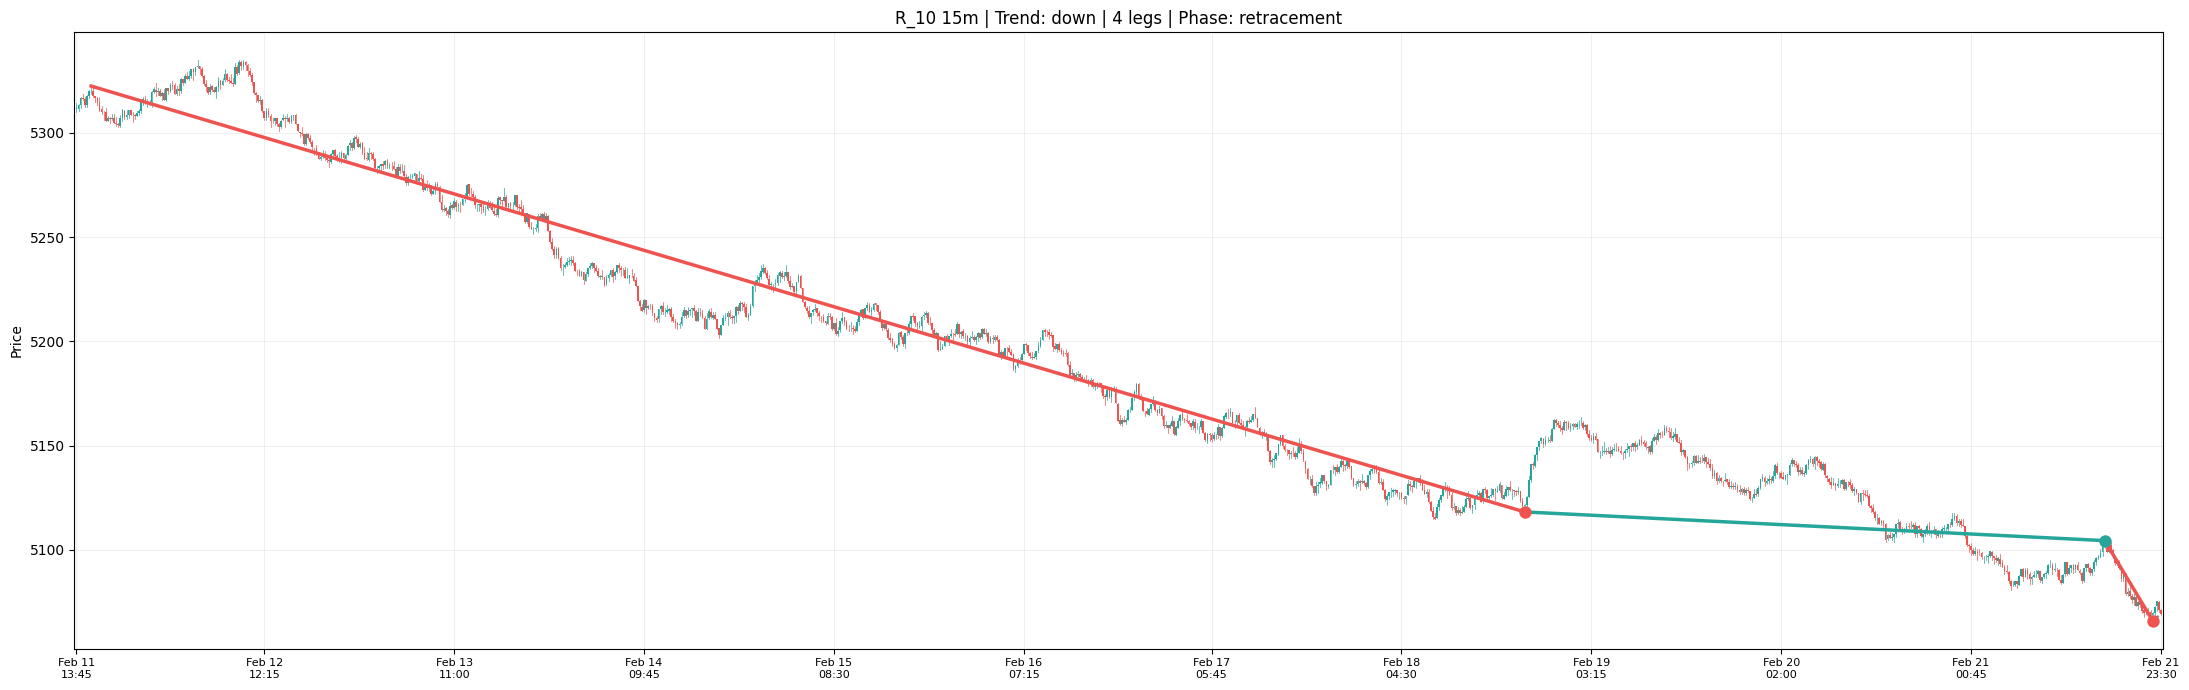

1H: 1000 candles | trend=down | legs=6 | phase=retracement


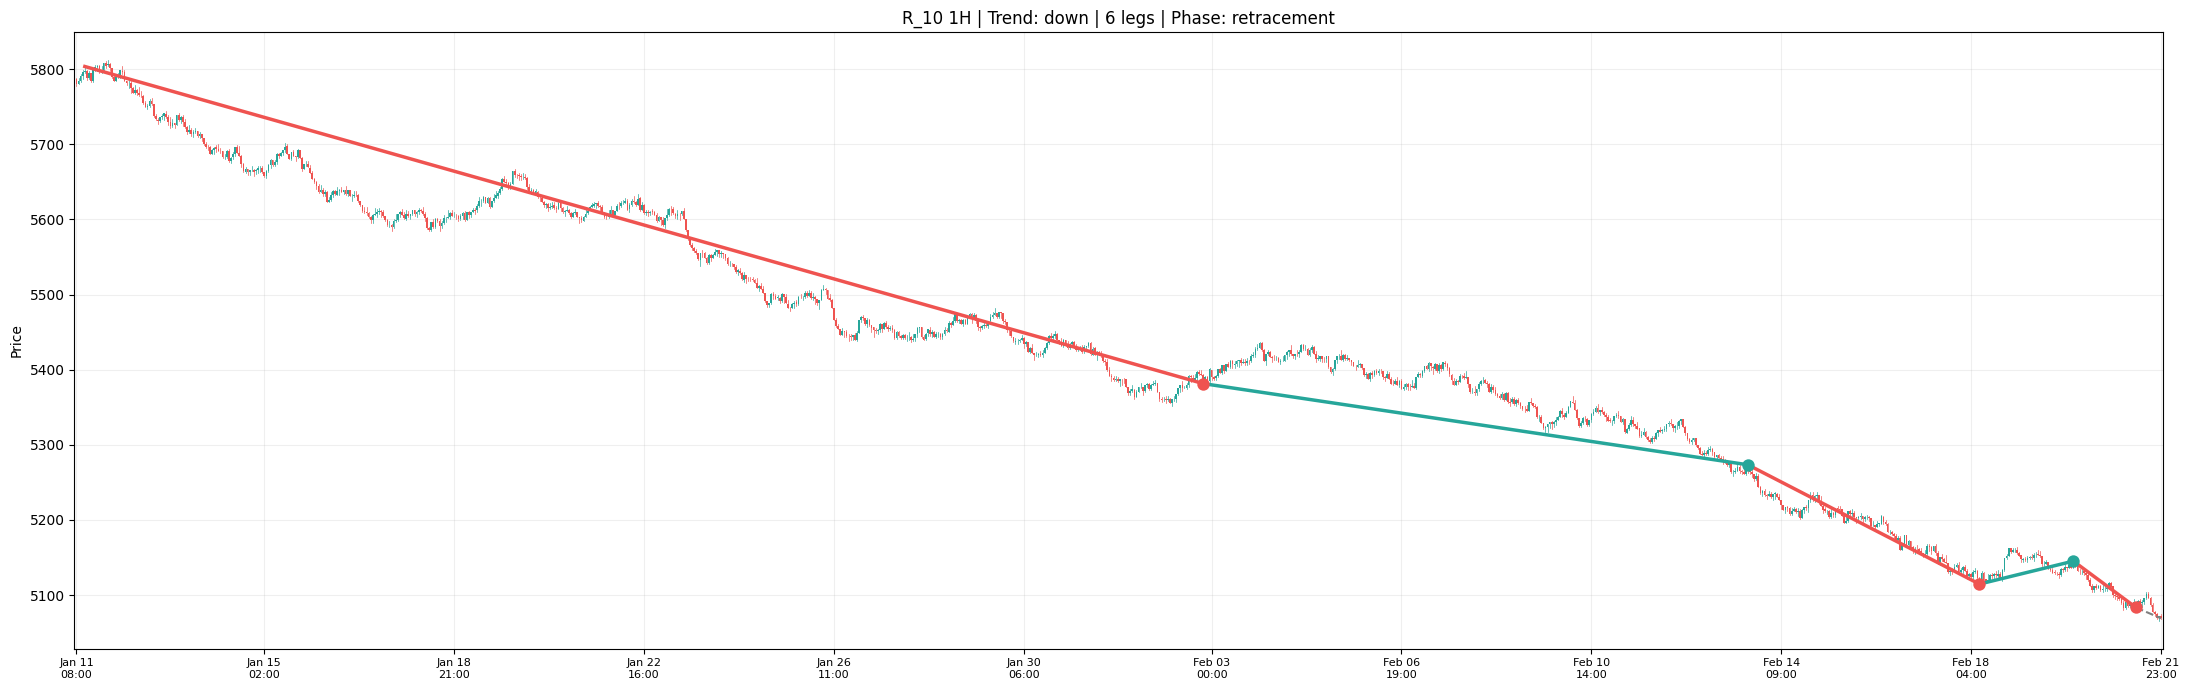

Skipping R_10_4H.csv — file not found
D: 366 candles | trend=down | legs=4 | phase=retracement


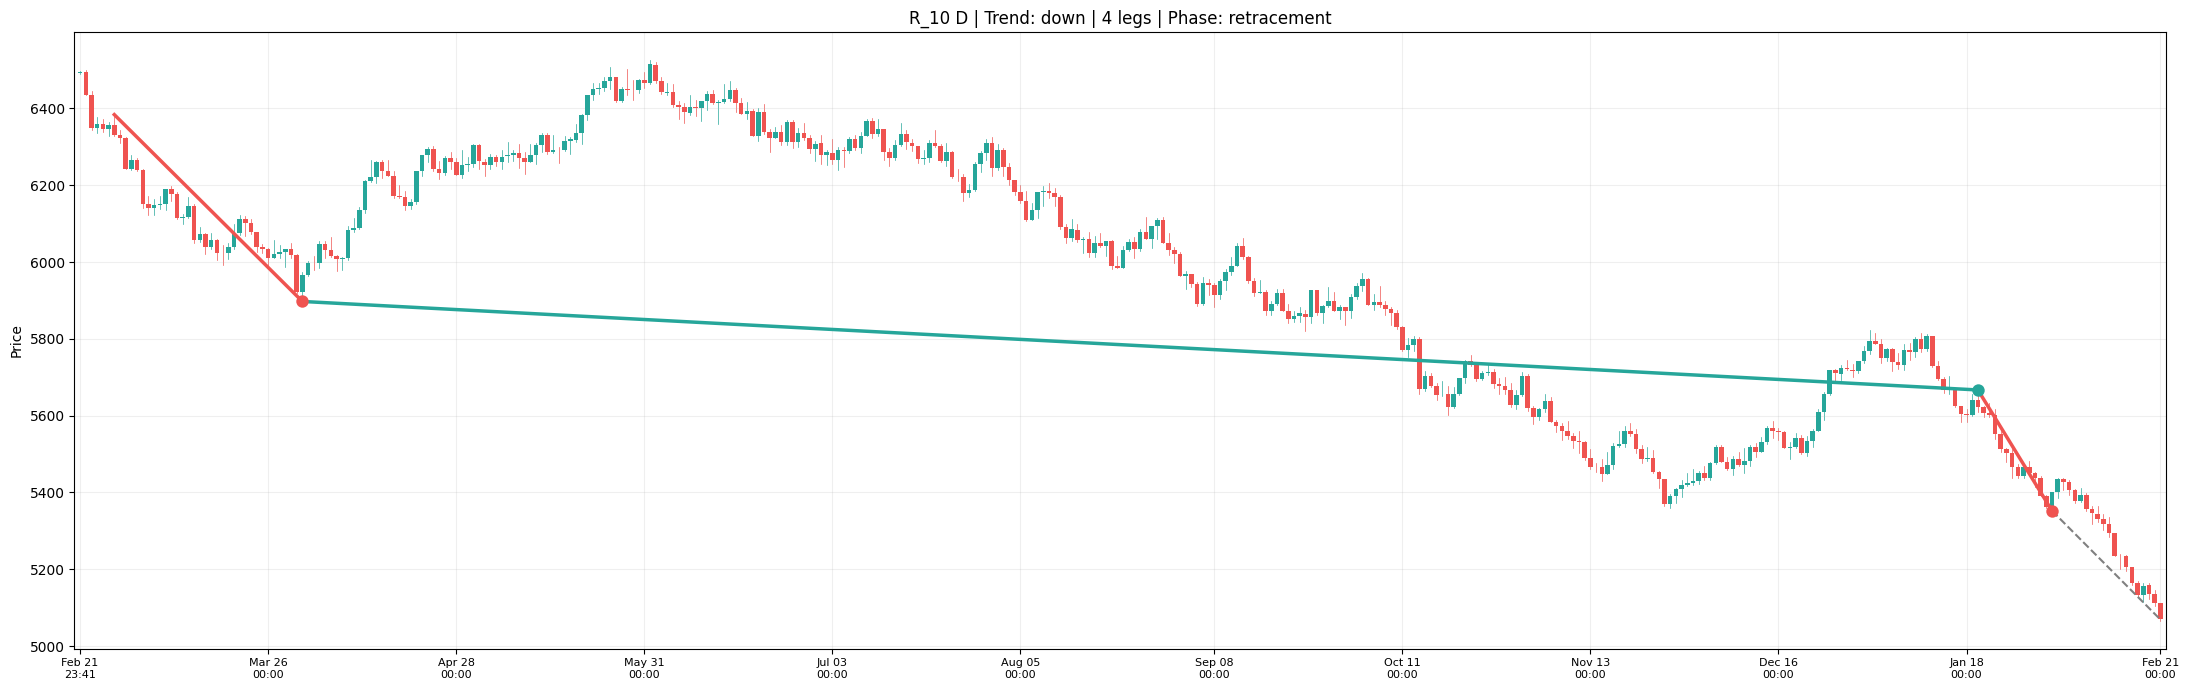

In [30]:
# Cell 5 — Multi-timeframe sweep (R_10, all timeframes)
import sys as _sys
import yaml as _yaml
import matplotlib.pyplot as _plt
from datetime import timedelta as _td
from pathlib import Path as _Path
from matplotlib.patches import Rectangle as _Rect

_ROOT = _Path('..').resolve()
if str(_ROOT) not in _sys.path:
    _sys.path.insert(0, str(_ROOT))

from src.adapters.local_data import load_ohlc_from_csv as _load
from src.core.trend_id import identify_trend as _identify

with open(_ROOT / 'config' / 'timeframe_windows.yaml') as _f:
    _tf_cfg = _yaml.safe_load(_f)['timeframes']

def _filter(candles, tf_key):
    days = _tf_cfg[tf_key]['lookback_days']
    cutoff = candles[-1].timestamp - _td(days=days)
    return [c for c in candles if c.timestamp >= cutoff]

_UP = '#26a69a'
_DN = '#ef5350'

def _draw(candles, result, symbol, timeframe):
    WINDOW  = len(candles)
    trend   = result['trend']
    legs    = result['legs']
    phase   = result['current_phase']

    fig, ax = _plt.subplots(figsize=(22, 7))

    # Candles
    for i, c in enumerate(candles):
        col     = _UP if c.close >= c.open else _DN
        body_lo = min(c.open, c.close)
        body_hi = max(c.open, c.close)
        body_h  = max(body_hi - body_lo, (c.high - c.low) * 0.01)
        ax.plot([i, i], [c.low, c.high], color=col, linewidth=0.5, zorder=1)
        ax.add_patch(_Rect(
            (i - 0.4, body_lo), 0.8, body_h,
            facecolor=col, edgecolor=col, linewidth=0, zorder=2))

    # Legs
    for leg in legs:
        sx = leg['start_index']
        sy = leg['start_price']
        ex = leg['end_index']   if leg['end_index']   is not None else WINDOW - 1
        ey = leg['end_price']   if leg['end_price']   is not None else candles[-1].close

        if leg['confirmed']:
            lc = (_DN if leg['type'] == 'impulse' else _UP) if trend == 'down' \
                 else (_UP if leg['type'] == 'impulse' else _DN)
            dc = _DN if leg['type'] == 'impulse' else _UP
            ax.plot([sx, ex], [sy, ey], color=lc, linewidth=2.5, zorder=4)
            ax.scatter(ex, ey, color=dc, s=80, zorder=6, linewidths=0)
        else:
            ax.plot([sx, ex], [sy, ey],
                    color='grey', linewidth=1.5, linestyle='--', zorder=3)

    # X-axis
    n_ticks  = 12
    tick_pos = [int(i * (WINDOW - 1) / (n_ticks - 1)) for i in range(n_ticks)]
    tick_lbl = [candles[i].timestamp.strftime('%b %d\n%H:%M') for i in tick_pos]
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_lbl, fontsize=8)
    ax.set_xlim(-1, WINDOW)
    ax.set_ylabel('Price', fontsize=10)
    ax.grid(True, alpha=0.2)
    ax.set_title(
        f"R_10 {timeframe} | Trend: {trend} | {len(legs)} legs | Phase: {phase}",
        fontsize=12)
    _plt.tight_layout()
    _plt.show()


# ── Sweep ─────────────────────────────────────────────────────────────────────
_proc = _ROOT / 'data' / 'processed'

TF_SPECS = [
    ("1m",  "R_10_1m.csv",  "1m"),
    ("5m",  "R_10_5m.csv",  "5m"),
    ("15m", "R_10_15m.csv", "15m"),
    ("1H",  "R_10_1H.csv",  "1h"),
    ("4H",  "R_10_4H.csv",  "4h"),
    ("D",   "R_10_D.csv",   "1d"),
]

for tf_label, filename, cfg_key in TF_SPECS:
    csv_path = _proc / filename
    if not csv_path.exists():
        print(f"Skipping {filename} — file not found")
        continue
    raw     = _load(csv_path)
    candles = _filter(raw, cfg_key)
    result  = _identify(candles)
    print(f"{tf_label}: {len(candles)} candles | "
          f"trend={result['trend']} | "
          f"legs={len(result['legs'])} | "
          f"phase={result['current_phase']}")
    _draw(candles, result, "R_10", tf_label)